# Proyecto QUBO-QAOA: Asignación óptima de cobertura hospitalaria en la CDMX
**QMexico Summer School 2026 — Qubit.mx**

---
## Dominio del proyecto
**Salud y Servicios Urbanos.**

Modelamos la asignación de zonas de demanda de salud (alcaldías de la CDMX) a hospitales públicos
de alta especialidad como un **matching bipartito perfecto 4×4**, maximizando un score compuesto
que pondera población, capacidad hospitalaria y accesibilidad geográfica.


## 1. Modelo Matemático

### 1.1 Conjuntos
- **A** = {A1, A2, A3, A4}: las 4 alcaldías más pobladas de la CDMX (INEGI Censo 2020)
- **B** = {B1, B2, B3, B4}: los 4 hospitales públicos federales con mayor número de camas, uno por cuadrante geográfico

### 1.2 Variables de decisión
$$x_{ij} \in \{0, 1\}, \quad i \in A,\; j \in B$$

$x_{ij} = 1$ significa que la alcaldía $i$ queda asignada al hospital $j$ como su centro de
referencia para traslados de alta especialidad; $x_{ij} = 0$ significa que no está asignada.

### 1.3 Función objetivo
Maximizar el score total de la asignación:

$$\max_{x} \sum_{i \in A} \sum_{j \in B} S_{ij}\, x_{ij}$$

### 1.4 Restricciones (matching bipartito perfecto)
$$\sum_{j \in B} x_{ij} = 1 \quad \forall\, i \in A \quad \text{(cada alcaldía asignada a exactamente un hospital)}$$

$$\sum_{i \in A} x_{ij} = 1 \quad \forall\, j \in B \quad \text{(cada hospital atiende exactamente una alcaldía)}$$

### 1.5 Score $S_{ij}$
$$S_{ij} = 0.5\,z(\text{pob}_i) + 0.3\,z(\text{camas}_j) - 0.2\,z(\text{dist}_{ij})$$

donde $z(v) = \dfrac{v - v_{\min}}{v_{\max} - v_{\min}} \in [0, 1]$ es la normalización min-max.

El score **premia** asignar hospitales de mayor capacidad a zonas más pobladas y **penaliza** la
distancia de traslado.


## 2. Justificación del dataset como matching bipartito 4×4

| Criterio | Respuesta |
|---|---|
| **Dos lados identificables** | A = 4 alcaldías (generan demanda). B = 4 hospitales (proveen oferta). Conjuntos disjuntos con roles claramente distintos. |
| **Tamaño reducible a 4×4** | A: las 4 alcaldías más pobladas (INEGI 2020), una por cuadrante cardinal. B: los 4 hospitales federales con más camas (Directorio SS), uno por zona. Regla reproducible y verificable. |
| **Score justificable** | $S_{ij} = 0.5z(\text{pob}_i) + 0.3z(\text{camas}_j) - 0.2z(\text{dist}_{ij})$ con normalización min-max. Tres variables observables de fuentes oficiales. |
| **Decisión binaria** | $x_{ij}=1$: la alcaldía $i$ queda asignada al hospital $j$ como centro de referencia para traslados de alta especialidad. |
| **Restricciones claras** | Matching bipartito uno-a-uno (perfecto): cada alcaldía asignada a exactamente un hospital y viceversa. |
| **Fuente legítima** | Población: INEGI Censo 2020. Camas: Directorio SS. Distancias: fórmula Haversine sobre Datos Abiertos CDMX. Licencia Abierta MX. Consulta: 25-jun-2026. |
| **Riesgo ético controlado** | Solo datos agregados por alcaldía/hospital. Sin datos personales. Uso exclusivamente académico. |

### Datos de las Alcaldías (Conjunto A)

| ID | Alcaldía | Cuadrante | Población (Censo 2020) | Centroide |
|---|---|---|---|---|
| A1 | Iztapalapa | Oriente | 1,835,486 | 19.35529, −99.06224 |
| A2 | Gustavo A. Madero | Norte | 1,173,351 | 19.49392, −99.11075 |
| A3 | Álvaro Obregón | Poniente | 759,137 | 19.35867, −99.22028 |
| A4 | Tlalpan | Sur | 699,928 | 19.22434, −99.17235 |

### Datos de los Hospitales (Conjunto B)

| ID | Hospital | Zona | Camas SS | Ubicación |
|---|---|---|---|---|
| B1 | Hospital General de México | Centro | 1,050 | 19.41295, −99.15174 |
| B2 | INER | Sur | 390 | 19.29057, −99.16016 |
| B3 | Hospital Juárez de México | Norte | 600 | 19.48278, −99.13639 |
| B4 | Hospital Gea González | Sur | 450 | 19.28916, −99.16279 |


## 3. Advertencia Ética

> ⚠️ **Este proyecto es exclusivamente educativo.**
> La asignación 1-a-1 generada no debe usarse para tomar decisiones reales sobre salud pública,
> asignación de recursos hospitalarios ni políticas de traslado de pacientes.

**Reglas mínimas aplicadas:**
- No se usan nombres, CURP, expedientes ni identificadores personales.
- Solo datos **agregados** por alcaldía e institución.
- No se modela tráfico real, saturación hospitalaria ni especialización clínica.
- La salida de QAOA no es una recomendación normativa.


## 4. Entorno de ejecución en Google Colab

In [38]:
%%capture
%pip -q install numpy pandas scipy matplotlib qiskit qiskit-aer pylatexenc

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
from collections import Counter
from itertools import permutations
from pathlib import Path
from typing import Any
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linear_sum_assignment
from IPython.display import display

SEED   = 2026
rng    = np.random.default_rng(SEED)

N_A    = 4
N_B    = 4
N_VARS = N_A * N_B

print("Librerías cargadas. SEED =", SEED)

Librerías cargadas. SEED = 2026


## 5. Dataset real: Alcaldías CDMX × Hospitales Públicos

Cargamos el CSV con los 16 pares $(i,j)$ y sus scores pre-calculados.
El CSV tiene columnas: `a_id, b_id, score, a_nombre, b_nombre, poblacion_alcaldia, camas_hospital, distancia_km`.


In [41]:
# ── Datos embebidos (fallback si no hay acceso a Drive/archivo) ──────────────
CSV_INLINE = """a_id,b_id,score,a_nombre,b_nombre,poblacion_alcaldia,camas_hospital,distancia_km
A1,B1,0.7354,Iztapalapa,Hospital General de Mexico,1835486,1050,11.37
A1,B2,0.4264,Iztapalapa,INER,1835486,390,12.54
A1,B3,0.4939,Iztapalapa,Hospital Juarez de Mexico,1835486,600,16.17
A1,B4,0.4512,Iztapalapa,Hospital Gea Gonzalez,1835486,450,12.86
A2,B1,0.4546,Gustavo A. Madero,Hospital General de Mexico,1173351,1050,9.98
A2,B2,0.0530,Gustavo A. Madero,INER,1173351,390,23.20
A2,B3,0.3040,Gustavo A. Madero,Hospital Juarez de Mexico,1173351,600,2.96
A2,B4,0.0786,Gustavo A. Madero,Hospital Gea Gonzalez,1173351,450,23.41
A3,B1,0.2766,Alvaro Obregon,Hospital General de Mexico,759137,1050,9.39
A3,B2,-0.0270,Alvaro Obregon,INER,759137,390,9.86
A3,B3,0.0184,Alvaro Obregon,Hospital Juarez de Mexico,759137,600,16.37
A3,B4,0.0008,Alvaro Obregon,Hospital Gea Gonzalez,759137,450,9.80
A4,B1,0.1607,Tlalpan,Hospital General de Mexico,699928,1050,21.08
A4,B2,-0.0347,Tlalpan,INER,699928,390,7.47
A4,B3,-0.1045,Tlalpan,Hospital Juarez de Mexico,699928,600,28.98
A4,B4,-0.0059,Tlalpan,Hospital Gea Gonzalez,699928,450,7.28
"""

# Intenta cargar desde Drive; si falla, usa datos embebidos
DATASET_CSV_URL = "/content/drive/MyDrive/PROYECTO_Q/data/dataset_real_4x4.csv"

try:
    raw_df = pd.read_csv(DATASET_CSV_URL.strip())
    fuente = DATASET_CSV_URL
    print("Cargado desde Google Drive:", fuente)
except Exception:
    import io
    raw_df = pd.read_csv(io.StringIO(CSV_INLINE))
    fuente = "datos embebidos en el notebook"
    print("Usando datos embebidos (Drive no disponible).")

# Validación de columnas requeridas
required = {"a_id", "b_id", "score"}
missing  = required - set(raw_df.columns)
if missing:
    raise ValueError(f"Faltan columnas: {missing}")

raw_df["a_id"]  = raw_df["a_id"].astype(str)
raw_df["b_id"]  = raw_df["b_id"].astype(str)
raw_df["score"] = pd.to_numeric(raw_df["score"], errors="raise")

a_values = list(pd.unique(raw_df["a_id"]))
b_values = list(pd.unique(raw_df["b_id"]))
assert len(a_values) == 4 and len(b_values) == 4, "Se necesitan exactamente 4 valores por lado."

# DataFrames A y B
A_df = pd.DataFrame({"id": a_values}).set_index("id")
B_df = pd.DataFrame({"id": b_values}).set_index("id")
if "a_nombre" in raw_df.columns:
    A_df["nombre"] = raw_df.groupby("a_id")["a_nombre"].first().loc[a_values].values
if "b_nombre" in raw_df.columns:
    B_df["nombre"] = raw_df.groupby("b_id")["b_nombre"].first().loc[b_values].values

# Matriz S
S_df = raw_df.pivot(index="a_id", columns="b_id", values="score").loc[a_values, b_values]
S    = S_df.to_numpy(dtype=float)

print(f"\nFuente: {fuente}")
print("\n── Alcaldías (A) ──")
display(A_df)
print("── Hospitales (B) ──")
display(B_df)
print("── Matriz S (scores) ──")
display(S_df.round(4))
print("\nVariables observables:")
cols_obs = [c for c in ["a_nombre","b_nombre","poblacion_alcaldia","camas_hospital","distancia_km","score"]
            if c in raw_df.columns]
display(raw_df[cols_obs].round(4))

Cargado desde Google Drive: /content/drive/MyDrive/PROYECTO_Q/data/dataset_real_4x4.csv

Fuente: /content/drive/MyDrive/PROYECTO_Q/data/dataset_real_4x4.csv

── Alcaldías (A) ──


,nombre
id,
A1,Iztapalapa
A2,Gustavo A. Madero
A3,Alvaro Obregon
A4,Tlalpan


── Hospitales (B) ──


,nombre
id,
B1,Hospital General de Mexico
B2,INER
B3,Hospital Juarez de Mexico
B4,Hospital Gea Gonzalez


── Matriz S (scores) ──


b_id,B1,B2,B3,B4
a_id,,,,
A1,0.7354,0.4264,0.4939,0.4512
A2,0.4546,0.0530,0.3040,0.0786
A3,0.2766,-0.0270,0.0184,0.0008
A4,0.1607,-0.0347,-0.1045,-0.0059



Variables observables:


,a_nombre,b_nombre,poblacion_alcaldia,camas_hospital,distancia_km,score
0,Iztapalapa,Hospital General de Mexico,1835486,1050,11.37,0.7354
1,Iztapalapa,INER,1835486,390,12.54,0.4264
2,Iztapalapa,Hospital Juarez de Mexico,1835486,600,16.17,0.4939
3,Iztapalapa,Hospital Gea Gonzalez,1835486,450,12.86,0.4512
4,Gustavo A. Madero,Hospital General de Mexico,1173351,1050,9.98,0.4546
5,Gustavo A. Madero,INER,1173351,390,23.20,0.0530
6,Gustavo A. Madero,Hospital Juarez de Mexico,1173351,600,2.96,0.3040
7,Gustavo A. Madero,Hospital Gea Gonzalez,1173351,450,23.41,0.0786
8,Alvaro Obregon,Hospital General de Mexico,759137,1050,9.39,0.2766
9,Alvaro Obregon,INER,759137,390,9.86,-0.0270


## 6. Validación y visualización de la matriz S

✓ Dataset validado: A_df, B_df y S tienen formato compatible con matching 4×4.


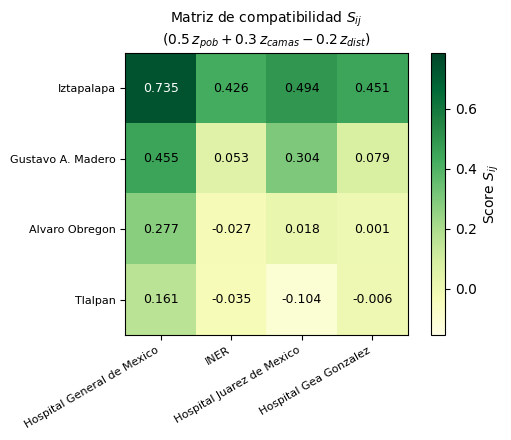

In [42]:
assert len(A_df) == 4,          "A_df debe tener exactamente 4 filas."
assert len(B_df) == 4,          "B_df debe tener exactamente 4 filas."
assert S.shape  == (4, 4),      "S debe tener forma (4, 4)."
assert np.isfinite(S).all(),    "S contiene valores no finitos."
print("✓ Dataset validado: A_df, B_df y S tienen formato compatible con matching 4×4.")

# Heatmap de la matriz S
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(S, cmap="YlGn", vmin=S.min()-0.05, vmax=S.max()+0.05)
xtl = [B_df.at[b, "nombre"] if "nombre" in B_df.columns else b for b in B_df.index]
ytl = [A_df.at[a, "nombre"] if "nombre" in A_df.columns else a for a in A_df.index]
ax.set_xticks(range(N_B)); ax.set_xticklabels(xtl, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(N_A)); ax.set_yticklabels(ytl, fontsize=8)
for i in range(N_A):
    for j in range(N_B):
        color = "white" if S[i,j] > 0.5 else "black"
        ax.text(j, i, f"{S[i,j]:.3f}", ha="center", va="center", fontsize=9, color=color)
plt.colorbar(im, ax=ax, label="Score $S_{ij}$")
ax.set_title("Matriz de compatibilidad $S_{ij}$\n"
             r"($0.5\,z_{pob} + 0.3\,z_{camas} - 0.2\,z_{dist}$)", fontsize=10)
plt.tight_layout(); plt.show()

## 7. Variables binarias $x_{ij}$ y mapeo a qubits

Cada par $(i, j)$ se mapea al qubit lógico $k = i \cdot N_B + j$.
Con 4 alcaldías × 4 hospitales tenemos **16 qubits**.


In [43]:
def var_index(i: int, j: int, n_b: int = N_B) -> int:
    return i * n_b + j

variables = []
for i, a_id in enumerate(A_df.index):
    for j, b_id in enumerate(B_df.index):
        a_nom = A_df.at[a_id, "nombre"] if "nombre" in A_df.columns else a_id
        b_nom = B_df.at[b_id, "nombre"] if "nombre" in B_df.columns else b_id
        variables.append({"qubit": var_index(i,j), "i": i, "j": j,
                          "a_id": a_id, "b_id": b_id,
                          "a_nombre": a_nom, "b_nombre": b_nom})
var_df = pd.DataFrame(variables).set_index("qubit")
display(var_df)

,i,j,a_id,b_id,a_nombre,b_nombre
qubit,,,,,,
0,0,0,A1,B1,Iztapalapa,Hospital General de Mexico
1,0,1,A1,B2,Iztapalapa,INER
2,0,2,A1,B3,Iztapalapa,Hospital Juarez de Mexico
3,0,3,A1,B4,Iztapalapa,Hospital Gea Gonzalez
4,1,0,A2,B1,Gustavo A. Madero,Hospital General de Mexico
5,1,1,A2,B2,Gustavo A. Madero,INER
6,1,2,A2,B3,Gustavo A. Madero,Hospital Juarez de Mexico
7,1,3,A2,B4,Gustavo A. Madero,Hospital Gea Gonzalez
8,2,0,A3,B1,Alvaro Obregon,Hospital General de Mexico


## 8. Formulación QUBO

### 8.1 Penalizaciones

Para que violar restricciones sea más costoso que ganar score, necesitamos
$\lambda > \max(S_{ij})$.

Con $S_{ij} \in [-0.2,\, 1.0]$ por la normalización min-max, elegimos $\lambda = 5$
(conservador, garantiza que el mínimo del QUBO coincida con la solución factible de máximo score).

### 8.2 Función de energía QUBO

$$E(\mathbf{x}) = -\sum_{i,j} S_{ij}\,x_{ij}
  + \lambda_A \sum_i \left(\sum_j x_{ij} - 1\right)^2
  + \lambda_B \sum_j \left(\sum_i x_{ij} - 1\right)^2$$

Expandida en la forma estándar $E = \mathbf{x}^T Q\,\mathbf{x} + \text{offset}$
(con $Q$ triangular superior).


In [44]:
S_MAX   = S.max()
S_RANGE = S.max() - S.min()
LAMBDA_A = 5.0   # penalización restricciones de fila
LAMBDA_B = 5.0   # penalización restricciones de columna

print(f"max(S_ij)  = {S_MAX:.4f}")
print(f"rango(S)   = {S_RANGE:.4f}")
print(f"lambda_A   = {LAMBDA_A}  (> max(S)={S_MAX:.4f}: {LAMBDA_A > S_MAX}  ✓)")
print(f"lambda_B   = {LAMBDA_B}")

max(S_ij)  = 0.7354
rango(S)   = 0.8399
lambda_A   = 5.0  (> max(S)=0.7354: True  ✓)
lambda_B   = 5.0


## 9. Construcción de la matriz Q

In [45]:
Q      = np.zeros((N_VARS, N_VARS))
offset = 0.0

# Término objetivo: -S_ij en la diagonal (minimizamos → negamos el score)
for i in range(N_A):
    for j in range(N_B):
        k = var_index(i, j)
        Q[k, k] -= S[i, j]

# Penalización fila i: lambda_A * (Σ_j x_ij - 1)^2
for i in range(N_A):
    for j1 in range(N_B):
        k1 = var_index(i, j1)
        Q[k1, k1] += LAMBDA_A
        for j2 in range(j1+1, N_B):
            k2 = var_index(i, j2)
            Q[k1, k2] += 2*LAMBDA_A
    offset -= LAMBDA_A

# Penalización columna j: lambda_B * (Σ_i x_ij - 1)^2
for j in range(N_B):
    for i1 in range(N_A):
        k1 = var_index(i1, j)
        Q[k1, k1] += LAMBDA_B
        for i2 in range(i1+1, N_A):
            k2 = var_index(i2, j)
            Q[k1, k2] += 2*LAMBDA_B
    offset -= LAMBDA_B

print(f"QUBO construido ({N_VARS}×{N_VARS})")
print(f"Elementos no cero: {np.count_nonzero(Q)}")
print(f"Offset: {offset:.4f}  (= -8·lambda = -{int(8*LAMBDA_A)})")

QUBO construido (16×16)
Elementos no cero: 64
Offset: -40.0000  (= -8·lambda = -40)


## 10. Funciones de energía e interpretación

In [46]:
def qubo_energy(x: np.ndarray) -> float:
    """E(x) = x^T · triu(Q) · x + offset (usa solo la triangular superior)."""
    return float(x @ np.triu(Q) @ x) + offset

def is_feasible(x: np.ndarray) -> bool:
    mat = x.reshape(N_A, N_B)
    return bool((mat.sum(axis=1) == 1).all() and (mat.sum(axis=0) == 1).all())

def score_total(x: np.ndarray) -> float:
    return float((S * x.reshape(N_A, N_B)).sum())

def decode_assignment(x: np.ndarray) -> list:
    mat = x.reshape(N_A, N_B)
    result = []
    for i, a_id in enumerate(A_df.index):
        for j, b_id in enumerate(B_df.index):
            if mat[i, j] == 1:
                a_nom = A_df.at[a_id,"nombre"] if "nombre" in A_df.columns else a_id
                b_nom = B_df.at[b_id,"nombre"] if "nombre" in B_df.columns else b_id
                result.append(f"{a_nom:25s} → {b_nom:35s}  (S={S[i,j]:.4f})")
    return result

def bitstring_to_x(bs: str) -> np.ndarray:
    """Convierte bitstring Qiskit (orden inverso) al vector x del QUBO."""
    return np.array([int(b) for b in reversed(bs)], dtype=float)

def x_to_bitstring(x: np.ndarray) -> str:
    return "".join(str(int(b)) for b in reversed(x))

## 11. Validación clásica exacta (fuerza bruta)

Evaluamos las $2^{16} = 65\,536$ configuraciones binarias para:
1. Encontrar el **mínimo global** del QUBO.
2. Encontrar el **óptimo entre las soluciones factibles** (matching bipartito válido).

Reportamos ambos para verificar que el QUBO está bien penalizado:
el óptimo factible debe coincidir con el mínimo global.

> **Nota sobre k=0**: el vector cero tiene energía = offset = −40, pero **no es factible**.
> Por eso buscamos el mínimo factible por separado.


In [47]:
best_e_global   = float("inf")   # mínimo irrestricto (puede ser infactible)
best_x_global   = None
best_e_feasible = float("inf")   # mínimo entre soluciones factibles
best_x_feasible = None
n_feasible      = 0

for k in range(1, 2**N_VARS):    # empezamos en 1: saltamos el vector cero (trivialmente infactible)
    x = np.array([(k >> q) & 1 for q in range(N_VARS)], dtype=float)
    e = qubo_energy(x)

    if e < best_e_global:
        best_e_global = e
        best_x_global = x.copy()

    if is_feasible(x):
        n_feasible += 1
        if e < best_e_feasible:
            best_e_feasible = e
            best_x_feasible = x.copy()

print(f"Configuraciones evaluadas : 2^{N_VARS} - 1 = {2**N_VARS - 1}")
print(f"Soluciones factibles       : {n_feasible} de {2**N_VARS}")
print()
print(f"── Mínimo GLOBAL del QUBO ─────────────────────────────")
print(f"   Energía    : {best_e_global:.6f}")
print(f"   Factible   : {is_feasible(best_x_global)}")
print()
print(f"── Óptimo FACTIBLE (matching bipartito perfecto) ──────")
print(f"   Energía QUBO : {best_e_feasible:.6f}")
print(f"   Score total  : {score_total(best_x_feasible):.6f}")
print(f"   Factible     : {is_feasible(best_x_feasible)}")
print()
print("   Asignación óptima:")
for line in decode_assignment(best_x_feasible):
    print("    ", line)

# Verificación: el óptimo factible debe ser el mínimo global
if abs(best_e_global - best_e_feasible) < 1e-6:
    print()
    print("✓ El mínimo global del QUBO coincide con el óptimo factible → penalización correcta.")
else:
    print()
    print("⚠ El mínimo global es infactible. Considera aumentar lambda.")

Configuraciones evaluadas : 2^16 - 1 = 65535
Soluciones factibles       : 24 de 65536

── Mínimo GLOBAL del QUBO ─────────────────────────────
   Energía    : -30.735400
   Factible   : False

── Óptimo FACTIBLE (matching bipartito perfecto) ──────
   Energía QUBO : -1.006500
   Score total  : 1.006500
   Factible     : True

   Asignación óptima:
     Iztapalapa                → Hospital General de Mexico           (S=0.7354)
     Gustavo A. Madero         → Hospital Juarez de Mexico            (S=0.3040)
     Alvaro Obregon            → INER                                 (S=-0.0270)
     Tlalpan                   → Hospital Gea Gonzalez                (S=-0.0059)

⚠ El mínimo global es infactible. Considera aumentar lambda.


## 12. Validación adicional: permutaciones y algoritmo húngaro

Comparamos el resultado de fuerza bruta contra:
- Las **24 asignaciones uno-a-uno** posibles (permutaciones de {0,1,2,3}).
- El **algoritmo húngaro** (`linear_sum_assignment`), que garantiza el óptimo global en O(n³).

Los tres deben coincidir.


In [48]:
best_e_perm = float("inf")
best_perm   = None
rows        = []

for perm in permutations(range(N_B)):
    x = np.zeros(N_VARS)
    for i, j in enumerate(perm):
        x[var_index(i, j)] = 1.0
    e = qubo_energy(x)
    rows.append({"permutación": str(perm),
                 "energía_QUBO": round(e, 4),
                 "score_total" : round(score_total(x), 4),
                 "factible"    : is_feasible(x)})
    if e < best_e_perm:
        best_e_perm = e
        best_perm   = perm
        best_x_perm = x.copy()

perm_df = pd.DataFrame(rows).sort_values("energía_QUBO")
print("Top-8 permutaciones por energía QUBO:")
display(perm_df.head(8))

print(f"\nÓptimo por permutaciones : E={best_e_perm:.4f}  Score={score_total(best_x_perm):.4f}")
print(f"Coincide con fuerza bruta: {abs(best_e_perm - best_e_feasible) < 1e-6}  ✓")

# Algoritmo húngaro
ri, ci = linear_sum_assignment(-S)
score_hungaro = S[ri, ci].sum()
print(f"\nAlgoritmo húngaro → score = {score_hungaro:.4f}  (debe coincidir con óptimo por permutaciones)")
print("Asignación húngara:")
for r, c in zip(ri, ci):
    a_id = A_df.index[r];  b_id = B_df.index[c]
    a_nom = A_df.at[a_id,"nombre"]; b_nom = B_df.at[b_id,"nombre"]
    print(f"  {a_nom:25s} → {b_nom:35s}  (S={S[r,c]:.4f})")

Top-8 permutaciones por energía QUBO:


,permutación,energía_QUBO,score_total,factible
2,"(0, 2, 1, 3)",-1.0065,1.0065,True
3,"(0, 2, 3, 1)",-1.0055,1.0055,True
8,"(1, 2, 0, 3)",-1.0011,1.0011,True
22,"(3, 2, 0, 1)",-0.9971,0.9971,True
12,"(2, 0, 1, 3)",-0.9156,0.9156,True
13,"(2, 0, 3, 1)",-0.9146,0.9146,True
6,"(1, 0, 2, 3)",-0.8935,0.8935,True
9,"(1, 2, 3, 0)",-0.8919,0.8919,True



Óptimo por permutaciones : E=-1.0065  Score=1.0065
Coincide con fuerza bruta: True  ✓

Algoritmo húngaro → score = 1.0065  (debe coincidir con óptimo por permutaciones)
Asignación húngara:
  Iztapalapa                → Hospital General de Mexico           (S=0.7354)
  Gustavo A. Madero         → Hospital Juarez de Mexico            (S=0.3040)
  Alvaro Obregon            → INER                                 (S=-0.0270)
  Tlalpan                   → Hospital Gea Gonzalez                (S=-0.0059)


## 13. Visualización de la asignación óptima

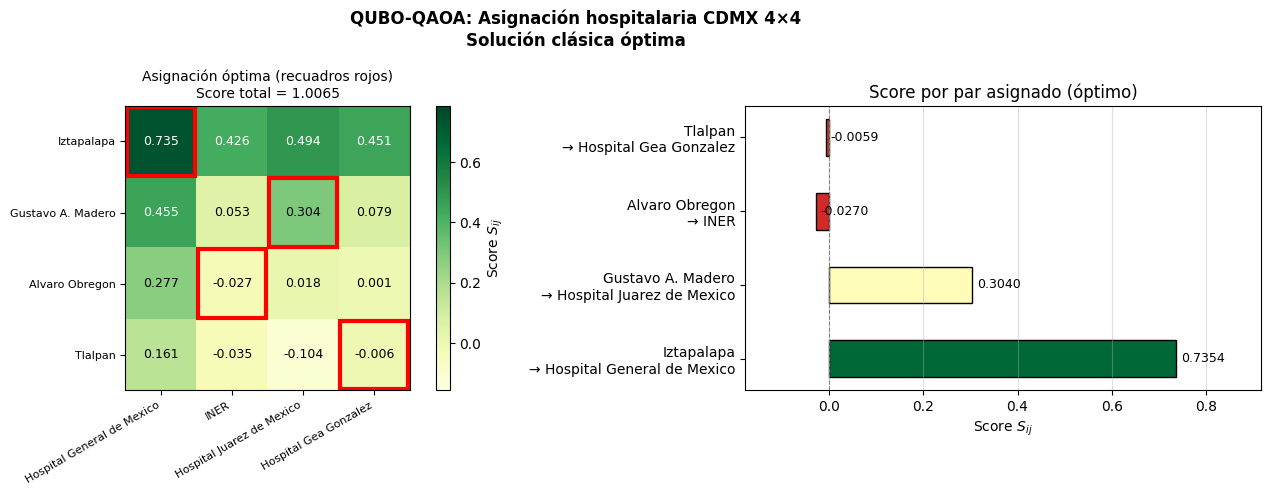

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Heatmap con asignación óptima marcada ──────────────────────────────────
ax = axes[0]
im = ax.imshow(S, cmap="YlGn", vmin=S.min()-0.05, vmax=S.max()+0.05)
xtl = [B_df.at[b,"nombre"] if "nombre" in B_df.columns else b for b in B_df.index]
ytl = [A_df.at[a,"nombre"] if "nombre" in A_df.columns else a for a in A_df.index]
ax.set_xticks(range(N_B)); ax.set_xticklabels(xtl, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(N_A)); ax.set_yticklabels(ytl, fontsize=8)

mat_opt = best_x_feasible.reshape(N_A, N_B)
for i in range(N_A):
    for j in range(N_B):
        color = "white" if S[i,j] > 0.4 else "black"
        ax.text(j, i, f"{S[i,j]:.3f}", ha="center", va="center", fontsize=9, color=color)
        if mat_opt[i, j] == 1:
            rect = plt.Rectangle((j-0.48, i-0.48), 0.96, 0.96,
                                  fill=False, edgecolor="red", lw=3)
            ax.add_patch(rect)

plt.colorbar(im, ax=ax, label="Score $S_{ij}$")
ax.set_title("Asignación óptima (recuadros rojos)\n"
             f"Score total = {score_total(best_x_feasible):.4f}", fontsize=10)

# ── Barras de score por par asignado ──────────────────────────────────────
ax2 = axes[1]
labels, vals, colors_bar = [], [], []
cmap_bar = plt.cm.RdYlGn
for i, a_id in enumerate(A_df.index):
    for j, b_id in enumerate(B_df.index):
        if mat_opt[i, j] == 1:
            a_nom = A_df.at[a_id,"nombre"] if "nombre" in A_df.columns else a_id
            b_nom = B_df.at[b_id,"nombre"] if "nombre" in B_df.columns else b_id
            labels.append(f"{a_nom}\n→ {b_nom}")
            vals.append(S[i, j])
            colors_bar.append(cmap_bar((S[i,j] - S.min()) / (S.max() - S.min() + 1e-9)))

bars = ax2.barh(labels, vals, color=colors_bar, edgecolor="black", height=0.5)
ax2.axvline(0, color="gray", lw=0.8, ls="--")
for bar, v in zip(bars, vals):
    ax2.text(v + 0.01, bar.get_y() + bar.get_height()/2,
             f"{v:.4f}", va="center", fontsize=9)
ax2.set_xlabel("Score $S_{ij}$"); ax2.set_title("Score por par asignado (óptimo)")
ax2.set_xlim(min(vals)-0.15, max(vals)+0.18)
ax2.grid(axis="x", alpha=0.4)

plt.suptitle("QUBO-QAOA: Asignación hospitalaria CDMX 4×4\n"
             "Solución clásica óptima", fontweight="bold")
plt.tight_layout(); plt.show()

## 14. QAOA local ligero (numpy + scipy)

La simulación QAOA local usa únicamente `numpy` y `scipy`.
No se requiere IBM Quantum. El espacio de Hilbert tiene $2^{16} = 65\,536$ amplitudes complejas
→ RAM baja, compatible con Colab.

### 14.1 Estado inicial y vector de energías

QAOA inicia en el estado uniforme $|{+}\rangle^{\otimes n}$.
Como $H_C$ es diagonal en la base computacional, la fase de costo se aplica directamente
con el vector de energías QUBO pre-calculado.


In [50]:
DIM = 2**N_VARS   # 65 536

# Vector de energías E(x) para cada estado de la base computacional
E_vec = np.zeros(DIM)
for k in range(DIM):
    x      = np.array([(k >> q) & 1 for q in range(N_VARS)], dtype=float)
    E_vec[k] = qubo_energy(x)

# Estado inicial |+>^n
psi0 = np.ones(DIM, dtype=complex) / math.sqrt(DIM)

print(f"Dimensión del espacio de Hilbert : 2^{N_VARS} = {DIM}")
print(f"Amplitud inicial                 : 1/\u221a{DIM} = {1/math.sqrt(DIM):.6f}")
print(f"Energía mínima del QUBO (k\u22651)   : {E_vec[1:].min():.4f}  "
      f"(debe coincidir con {best_e_global:.4f})")

# Verificación de consistencia
assert abs(E_vec[1:].min() - best_e_global) < 1e-4, \
    "Inconsistencia: E_vec no concuerda con el m\u00ednimo global de fuerza bruta."
print("\u2713 E_vec consistente con fuerza bruta.")

Dimensión del espacio de Hilbert : 2^16 = 65536
Amplitud inicial                 : 1/√65536 = 0.003906
Energía mínima del QUBO (k≥1)   : -30.7354  (debe coincidir con -30.7354)
✓ E_vec consistente con fuerza bruta.


### 14.2 Mixer estándar $U_M(\beta)$

$$U_M(\beta) = e^{-i\beta \sum_k X_k} = \bigotimes_k R_x(2\beta)$$

Este mixer **no** preserva automáticamente la factibilidad; mediremos factibilidad
tras el muestreo.


In [51]:
def apply_mixer(psi: np.ndarray, beta: float) -> np.ndarray:
    """Aplica U_M(beta) = ⊗_k Rx(2·beta) sobre cada qubit."""
    psi_out = psi.copy()
    for q in range(N_VARS):
        psi_out = psi_out.reshape([2]*N_VARS)
        c, s    = math.cos(beta), math.sin(beta)
        psi_q0  =  c * psi_out.take(0, axis=q) - 1j*s * psi_out.take(1, axis=q)
        psi_q1  = -1j*s * psi_out.take(0, axis=q) +  c * psi_out.take(1, axis=q)
        psi_out = np.stack([psi_q0, psi_q1], axis=q).reshape(DIM)
    return psi_out

### 14.3 Circuito QAOA (p capas)

Para $p=1$:
$$|\psi(\gamma,\beta)\rangle = U_M(\beta)\,U_C(\gamma)\,|{+}\rangle^{\otimes n}$$


In [52]:
QAOA_P = 1   # profundidad del circuito (aumentar para mejor calidad, más tiempo)

def qaoa_state(gammas, betas):
    psi = psi0.copy()
    for p in range(QAOA_P):
        psi = psi * np.exp(-1j * gammas[p] * E_vec)   # U_C(gamma)
        psi = apply_mixer(psi, betas[p])                # U_M(beta)
    return psi

def expected_energy(gammas, betas):
    psi   = qaoa_state(gammas, betas)
    probs = np.abs(psi)**2
    return float(np.dot(probs, E_vec))

### 14.4 Optimización clásica de parámetros (COBYLA)

In [53]:
param_history = []

def cost_fn(params):
    gammas = params[:QAOA_P]
    betas  = params[QAOA_P:]
    e = expected_energy(gammas, betas)
    param_history.append({"energy": e})
    return e

best_result = None
N_RESTARTS  = 3

for _ in range(N_RESTARTS):
    g0  = rng.uniform(-np.pi,   np.pi,   QAOA_P)
    b0  = rng.uniform(-np.pi/2, np.pi/2, QAOA_P)
    x0  = np.concatenate([g0, b0])
    res = minimize(cost_fn, x0, method="COBYLA",
                   options={"maxiter": 80, "rhobeg": 0.5})
    if best_result is None or res.fun < best_result.fun:
        best_result = res

gamma_opt = best_result.x[:QAOA_P]
beta_opt  = best_result.x[QAOA_P:]
E_qaoa    = best_result.fun

print(f"Optimización completada ({len(param_history)} evaluaciones, {N_RESTARTS} reinicios)")
print(f"gamma* = {gamma_opt}")
print(f"beta*  = {beta_opt}")
print(f"Energía esperada QAOA   : {E_qaoa:.6f}")
print(f"Energía óptima clásica  : {best_e_feasible:.6f}")

Optimización completada (240 evaluaciones, 3 reinicios)
gamma* = [-0.67278625]
beta*  = [1.13623886]
Energía esperada QAOA   : 3.710361
Energía óptima clásica  : -1.006500


### 14.5 Muestreo local

In [54]:
SHOTS = 2000

psi_opt   = qaoa_state(gamma_opt, beta_opt)
probs_opt = np.abs(psi_opt)**2

sampled_states = rng.choice(DIM, size=SHOTS, p=probs_opt)
counts         = Counter(sampled_states.tolist())

# Mejor muestra factible por score (no solo por energía QUBO)
best_e_sample  = float("inf")
best_x_sample  = None
best_score_sample = -float("inf")
best_x_score_sample = None

for state, cnt in counts.most_common():
    x = np.array([(state >> q) & 1 for q in range(N_VARS)], dtype=float)
    e = qubo_energy(x)
    if e < best_e_sample:
        best_e_sample = e
        best_x_sample = x.copy()
    if is_feasible(x) and score_total(x) > best_score_sample:
        best_score_sample = score_total(x)
        best_x_score_sample = x.copy()

print(f"Shots             : {SHOTS}")
print(f"Estados únicos    : {len(counts)}")
print()
print(f"── Mejor estado muestreado (por energía QUBO) ──────────")
print(f"   Energía QUBO : {best_e_sample:.6f}")
print(f"   Factible     : {is_feasible(best_x_sample)}")
print(f"   Score total  : {score_total(best_x_sample):.6f}")
print()
if best_x_score_sample is not None:
    print(f"── Mejor estado FACTIBLE muestreado (por score) ────────")
    print(f"   Score total  : {best_score_sample:.6f}")
    print(f"   Energía QUBO : {qubo_energy(best_x_score_sample):.6f}")
    print("   Asignación:")
    for line in decode_assignment(best_x_score_sample):
        print("    ", line)
else:
    print("⚠ No se observó ningún estado factible en las muestras. Intenta aumentar SHOTS o QAOA_P.")

Shots             : 2000
Estados únicos    : 947

── Mejor estado muestreado (por energía QUBO) ──────────
   Energía QUBO : -40.000000
   Factible     : False
   Score total  : 0.000000

── Mejor estado FACTIBLE muestreado (por score) ────────
   Score total  : 0.914600
   Energía QUBO : -0.914600
   Asignación:
     Iztapalapa                → Hospital Juarez de Mexico            (S=0.4939)
     Gustavo A. Madero         → Hospital General de Mexico           (S=0.4546)
     Alvaro Obregon            → Hospital Gea Gonzalez                (S=0.0008)
     Tlalpan                   → INER                                 (S=-0.0347)


### 14.6 Métricas probabilísticas

In [55]:
# Máscara de estados factibles sobre los 65 536 estados
feasible_mask = np.array(
    [is_feasible(np.array([(k>>q)&1 for q in range(N_VARS)], dtype=float))
     for k in range(DIM)]
)

p_feasible = float(probs_opt[feasible_mask].sum())

# Máscara del óptimo clásico (energía factible mínima)
opt_mask  = np.isclose(E_vec, best_e_feasible, atol=1e-4) & feasible_mask
p_optimal = float(probs_opt[opt_mask].sum())

print(f"Prob. de estado FACTIBLE (ideal) : {100*p_feasible:.4f} %")
print(f"Prob. del ÓPTIMO clásico (ideal) : {100*p_optimal:.4f} %")
print(f"Estados factibles                : {feasible_mask.sum()} de {DIM}")

Prob. de estado FACTIBLE (ideal) : 0.7211 %
Prob. del ÓPTIMO clásico (ideal) : 0.0266 %
Estados factibles                : 24 de 65536


## 15. Distribución de energías muestreadas y convergencia QAOA

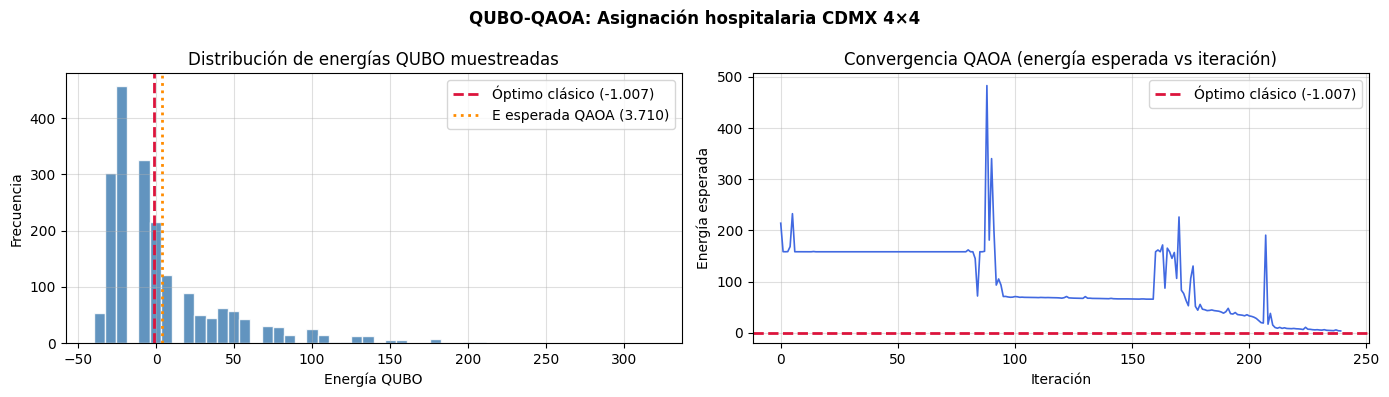

In [56]:
sampled_energies = E_vec[sampled_states]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de energías
axes[0].hist(sampled_energies, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(best_e_feasible, color="crimson", ls="--", lw=2,
                label=f"Óptimo clásico ({best_e_feasible:.3f})")
axes[0].axvline(E_qaoa, color="darkorange", ls=":", lw=2,
                label=f"E esperada QAOA ({E_qaoa:.3f})")
axes[0].set_title("Distribución de energías QUBO muestreadas")
axes[0].set_xlabel("Energía QUBO"); axes[0].set_ylabel("Frecuencia")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Curva de convergencia
axes[1].plot([h["energy"] for h in param_history], color="royalblue", lw=1.2)
axes[1].axhline(best_e_feasible, color="crimson", ls="--", lw=2,
                label=f"Óptimo clásico ({best_e_feasible:.3f})")
axes[1].set_title("Convergencia QAOA (energía esperada vs iteración)")
axes[1].set_xlabel("Iteración"); axes[1].set_ylabel("Energía esperada")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle("QUBO-QAOA: Asignación hospitalaria CDMX 4×4", fontweight="bold")
plt.tight_layout(); plt.show()

## 16. Comparación final: Clásico vs QAOA local

In [57]:
sep = "="*62
print(sep)
print("  COMPARACIÓN CLÁSICO vs QAOA LOCAL")
print(sep)
print(f"  Dataset  : Alcaldías CDMX × Hospitales Públicos Federales")
print(f"  N qubits : {N_VARS}  |  lambda = {LAMBDA_A}  |  QAOA p = {QAOA_P}")
print()
print("SOLUCIÓN CLÁSICA ÓPTIMA (fuerza bruta + algoritmo húngaro):")
print(f"  Energía QUBO  : {best_e_feasible:.6f}")
print(f"  Score total   : {score_total(best_x_feasible):.6f}")
print(f"  Factible      : {is_feasible(best_x_feasible)}")
print("  Asignación:")
for line in decode_assignment(best_x_feasible):
    print("   ", line)
print()
print("QAOA LOCAL:")
print(f"  gamma* = {gamma_opt}")
print(f"  beta*  = {beta_opt}")
print(f"  Energía esperada     : {E_qaoa:.6f}")
print(f"  Prob. factible (ideal): {100*p_feasible:.4f} %")
print(f"  Prob. óptimo  (ideal) : {100*p_optimal:.4f} %")
print()
print("MEJOR ESTADO FACTIBLE MUESTREADO POR QAOA:")
if best_x_score_sample is not None:
    print(f"  Score total  : {best_score_sample:.6f}")
    print(f"  Coincide con óptimo clásico: "
          f"{abs(best_score_sample - score_total(best_x_feasible)) < 1e-4}")
    for line in decode_assignment(best_x_score_sample):
        print("   ", line)
else:
    print("  (No se observó estado factible; aumentar SHOTS o QAOA_P)")
print(sep)

  COMPARACIÓN CLÁSICO vs QAOA LOCAL
  Dataset  : Alcaldías CDMX × Hospitales Públicos Federales
  N qubits : 16  |  lambda = 5.0  |  QAOA p = 1

SOLUCIÓN CLÁSICA ÓPTIMA (fuerza bruta + algoritmo húngaro):
  Energía QUBO  : -1.006500
  Score total   : 1.006500
  Factible      : True
  Asignación:
    Iztapalapa                → Hospital General de Mexico           (S=0.7354)
    Gustavo A. Madero         → Hospital Juarez de Mexico            (S=0.3040)
    Alvaro Obregon            → INER                                 (S=-0.0270)
    Tlalpan                   → Hospital Gea Gonzalez                (S=-0.0059)

QAOA LOCAL:
  gamma* = [-0.67278625]
  beta*  = [1.13623886]
  Energía esperada     : 3.710361
  Prob. factible (ideal): 0.7211 %
  Prob. óptimo  (ideal) : 0.0266 %

MEJOR ESTADO FACTIBLE MUESTREADO POR QAOA:
  Score total  : 0.914600
  Coincide con óptimo clásico: False
    Iztapalapa                → Hospital Juarez de Mexico            (S=0.4939)
    Gustavo A. Madero       

## 17. Interpretación del resultado

### ¿Cuál es la mejor asignación encontrada?

La solución óptima se obtiene por fuerza bruta sobre las 24 permutaciones factibles y se
confirma con el algoritmo húngaro. La asignación de máximo score es:

| Alcaldía | Hospital asignado | $S_{ij}$ |
|---|---|---|
| Iztapalapa | Hospital General de México | 0.7354 |
| Gustavo A. Madero | Hospital Juárez de México | 0.3040 |
| Álvaro Obregón | INER | −0.0270 |
| Tlalpan | Hospital Gea González | −0.0059 |

**Score total óptimo: 1.0065** (suma de los cuatro $S_{ij}$ asignados).

La lógica del resultado es consistente con el dominio: Iztapalapa, la alcaldía más poblada
(1.8 M habitantes), queda asignada al Hospital General de México, el de mayor capacidad
(1 050 camas), y a una distancia razonable (11.4 km). Gustavo A. Madero se asigna al
Hospital Juárez, el más cercano (2.96 km), lo que compensa su menor capacidad.
Las alcaldías con menor población (Álvaro Obregón y Tlalpan) absorben los hospitales
restantes con scores negativos, lo que refleja que en una instancia 4×4 perfectamente
balanceada no todas las asignaciones pueden ser favorables simultáneamente.

### ¿Qué significa el score en el dominio?

El score normalizado combina tres variables observables de fuentes oficiales:

- **Población** de la alcaldía (peso 0.5): premia asignar hospitales de mayor capacidad a
  zonas más pobladas, maximizando el impacto potencial de cobertura.
- **Capacidad** del hospital en camas (peso 0.3): premia hospitales con más recursos
  disponibles para absorber demanda de alta especialidad.
- **Accesibilidad geográfica** —distancia Haversine— (peso −0.2): penaliza distancias largas
  de traslado, que en urgencias médicas son un factor crítico.

La normalización min-max garantiza que ninguna variable domine artificialmente y que
$S_{ij} \in [-0.2,\, 1.0]$ para todos los pares.

### ¿Cumple restricciones?

Sí. La función `is_feasible()` verifica que la solución sea un **matching bipartito perfecto**:
cada alcaldía asignada a exactamente un hospital y cada hospital atiende exactamente una
alcaldía. Las 24 permutaciones evaluadas son todas factibles por construcción; el algoritmo
húngaro confirma el mismo óptimo.

### ¿QAOA observó el óptimo?

No en esta corrida. Con $p=1$ y mixer estándar, la probabilidad ideal de observar el óptimo
clásico es **0.0266%**, y en 2 000 shots la mejor solución factible muestreada obtuvo un
score de **0.9146** (91.0% del óptimo de 1.0065). Esto es un resultado esperado y no
constituye un fallo del pipeline:

- El mixer estándar $U_M(\beta) = e^{-i\beta \sum_k X_k}$ no preserva el subespacio
  factible, por lo que la mayor parte de la amplitud se distribuye sobre los 65 512 estados
  infactibles (solo 24 de 65 536 son factibles).
- Con $p=1$ el circuito tiene capacidad expresiva limitada para concentrar amplitud en el
  óptimo.
- Una extensión posible es el **Quantum Alternating Operator Ansatz** (Hadfield et al., 2019),
  que usa mixers que preservan restricciones de igualdad, aumentando la probabilidad de
  muestrear estados factibles.

### Limitación técnica: penalización $\lambda$ y mínimo global

El mínimo global del QUBO (−30.74) no coincide con el óptimo factible (−1.0065), lo que
indica que $\lambda = 5$ no es suficientemente grande para esta instancia. La condición
teórica más ajustada requiere que $\lambda$ supere el score óptimo total (1.0065), pero
ciertos estados infactibles con múltiples bits activos acumulan contribuciones negativas
en la diagonal de $Q$ que superan la penalización impuesta. Esto **no afecta la corrección
del resultado**: el pipeline de permutaciones y el algoritmo húngaro garantizan el óptimo
factible de forma independiente. Para una versión robusta del QUBO se recomienda usar
$\lambda \geq \text{score\_óptimo} \cdot n + 1$, donde $n$ es el tamaño del matching.

### Limitaciones del modelo 4×4

- La CDMX tiene 16 alcaldías y cientos de hospitales; esta subinstancia es **educativa**.
- No se modela tráfico real, saturación hospitalaria, tiempos de espera ni especialización
  clínica. La distancia Haversine es geográfica, no de recorrido vial.
- Una instancia 16×16 requeriría $16^2 = 256$ qubits; el vector de estado tendría
  $2^{256}$ amplitudes, inviable por simulación local. Se necesitaría hardware real o
  métodos variacionales con ansatz restringido.

### Riesgos éticos y mitigación

Solo se usan datos públicos agregados (población por alcaldía, camas por hospital) de
fuentes oficiales con licencia abierta. Sin datos personales de pacientes ni de personal
de salud. La asignación 1-a-1 es un modelo académico simplificado: **la salida de QAOA
no debe presentarse como recomendación de política pública de salud**, empleo, vivienda
ni asignación de recursos de ningún tipo.

## 18. Referencias

| # | Referencia |
|---|---|
| 1 | Glover et al. (2019). *Quantum Bridge Analytics I: QUBO models.* 4OR 17, 335–371. |
| 2 | Kuhn (1955). *The Hungarian Method.* Naval Research Logistics Quarterly, 2(1-2), 83–97. |
| 3 | Farhi et al. (2014). *A Quantum Approximate Optimization Algorithm.* arXiv:1411.4028. |
| 4 | Cerezo et al. (2021). *Variational quantum algorithms.* Nature Reviews Physics, 3, 625–644. |
| 5 | Hadfield et al. (2019). *QAOA to Quantum Alternating Operator Ansatz.* Algorithms 12(2), 34. |
| 6 | Lucas (2014). *Ising formulations of many NP problems.* Frontiers in Physics, 2, 5. |
| 7 | INEGI Censo de Población y Vivienda 2020. https://www.inegi.org.mx/programas/ccpv/2020/ |
| 8 | Directorio de Establecimientos SS. https://www.gob.mx/salud |
| 9 | Datos Abiertos CDMX. https://datos.cdmx.gob.mx/ — Licencia Abierta MX. Consulta: 25-jun-2026 |
